# Análisis Exploratorio de Datos (EDA) y Proceso ETL sobre Datos de Vivienda

Estudiante: Sara Cardona

En este cuaderno se lleva a cabo el procesamiento y análisis del conjunto de datos de vivienda obtenido de Kaggle. A través de técnicas de exploración y preparación de datos, se busca examinar la información disponible y adecuarla para su uso analítico.
El objetivo es:

*  Comprender la estructura del dataset.

*  Identificar patrones y relaciones entre variables.

*  Detectar valores faltantes y posibles anomalías.

*  Aplicar transformaciones necesarias para preparar los datos.

*  Generar un dataset limpio listo para análisis posterior o modelado.


# *Importar librerias*

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Descarga desde Kaggle
import kagglehub

# Manejo del sistema operativo
import os

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [2]:
# Descargar la última versión"yadavhim/housing-csv"

path = kagglehub.dataset_download("yadavhim/housing-csv")

# Cargar el fichero que se llama: tested.csv
df = pd.read_csv(path + "/housing.csv")




Using Colab cache for faster access to the 'housing-csv' dataset.


In [3]:
# Describir el dataset
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
# Orden del Dataset
df.shape

(20640, 10)

In [5]:
# Información del Dataset
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
# DataFrame cabecera
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
# Mostrar las ultimas 5 filas
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


### Objetivo del Análisis de Datos de Vivienda
El objetivo principal de este análisis exploratorio y proceso ETL es comprender las características del mercado de vivienda en California. Buscamos identificar factores clave que influyen en el valor mediano de las casas, analizar patrones geográficos, detectar anomalías y preparar los datos para futuros modelos predictivos.

### Descripción de las Variables del Dataset de Vivienda

| Variable             | Descripción                                                          | Tipo de Dato |
| :------------------- | :------------------------------------------------------------------- | :----------- |
| `longitude`          | Una medida de la ubicación geográfica de la vivienda en el eje este-oeste. | Numérico     |
| `latitude`           | Una medida de la ubicación geográfica de la vivienda en el eje norte-sur. | Numérico     |
| `housing_median_age` | Edad media de las casas en un bloque determinado.                      | Numérico     |
| `total_rooms`        | Número total de habitaciones en el bloque.                           | Numérico     |
| `total_bedrooms`     | Número total de dormitorios en el bloque.                             | Numérico     |
| `population`         | Población total en el bloque.                                        | Numérico     |
| `households`         | Número total de hogares en el bloque.                                  | Numérico     |
| `median_income`      | Ingreso mediano de los hogares en el bloque (en decenas de miles de USD). | Numérico     |
| `median_house_value` | Valor mediano de la casa para los hogares en el bloque (variable objetivo). | Numérico     |
| `ocean_proximity`    | Proximidad al océano de la vivienda ('<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'NEAR BAY', 'ISLAND'). | Categórico   |

# Graficos

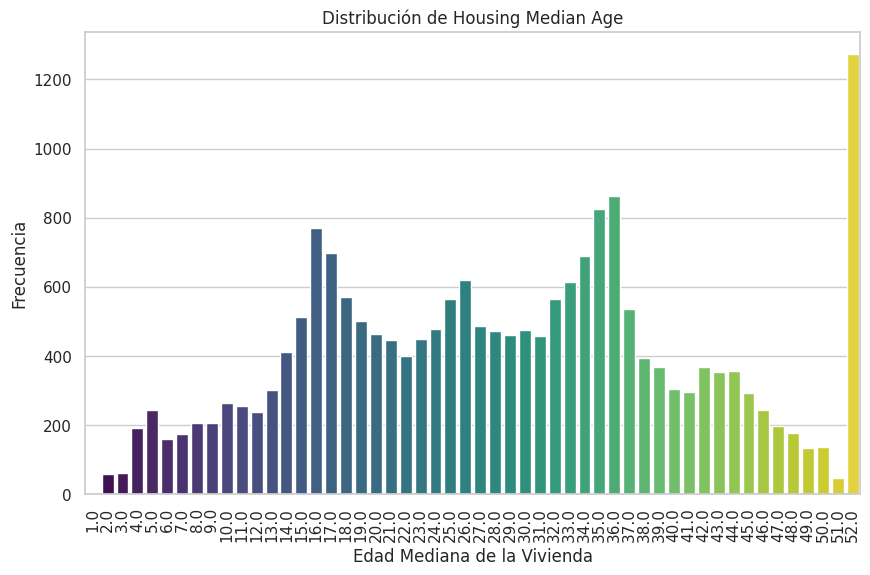

In [8]:
# Gráfico de barras de la variable
# Este gráfico muestra la proporción porcentual de cada categoría housing_median_age

plt.figure(figsize=(10, 6))
sns.countplot(x='housing_median_age', data=df, palette='viridis', hue='housing_median_age', legend=False)
plt.title('Distribución de Housing Median Age')
plt.xlabel('Edad Mediana de la Vivienda')
plt.ylabel('Frecuencia')
plt.xticks(rotation=90)
plt.show()

### Objetivo del Análisis para el Gráfico de Distribución de 'Housing Median Age'
El objetivo de este gráfico es visualizar la distribución de la edad mediana de las viviendas (`housing_median_age`) en el dataset. Esto nos permite entender cómo se agrupan las propiedades por su antigüedad, identificar si la mayoría de las casas son nuevas, antiguas, o si existe una distribución más uniforme, y detectar posibles anomalías o patrones interesantes en la edad de las viviendas.

### Descripción de la Variable Clave en el Gráfico

| Variable             | Descripción                                                          | Tipo de Dato |
| :------------------- | :------------------------------------------------------------------- | :----------- |
| `housing_median_age` | Edad mediana de las casas en un bloque determinado. Un valor más alto indica propiedades más antiguas en esa área. | Numérico     |


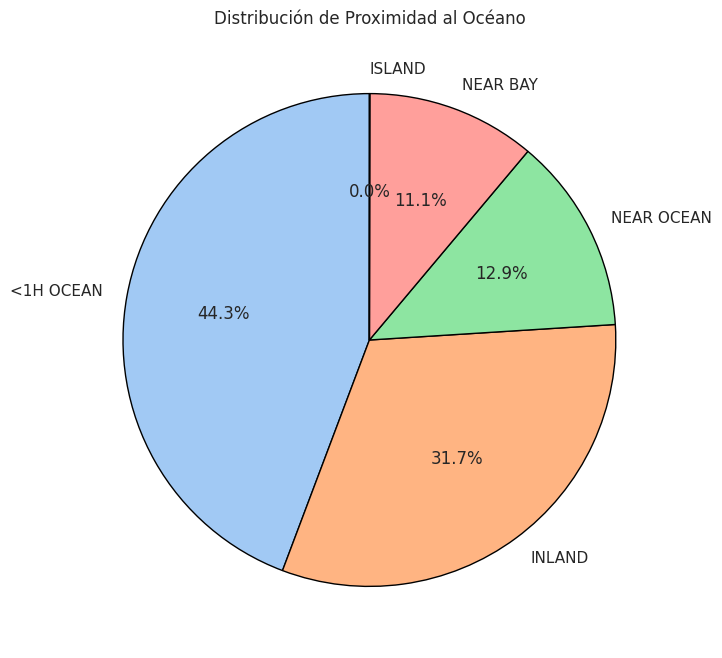

In [9]:
# Gráfico circular de la variable ocean_proximity
# Este gráfico muestra la proporción porcentual de cada categoría

plt.figure(figsize=(8, 8))

# Paleta pastel
colors = sns.color_palette('pastel')

# Conteo de categorías
counts = df['ocean_proximity'].value_counts()

counts.plot.pie(
    autopct='%1.1f%%',      # Mostrar porcentajes con un decimal
    startangle=90,          # Rotación inicial
    colors=colors,          # Colores pastel
    wedgeprops={'edgecolor': 'black'}  # Bordes para mejor visualización
)

plt.title('Distribución de Proximidad al Océano')
plt.ylabel('')  # Eliminar etiqueta del eje y
plt.show()

### Objetivo del Análisis para el Gráfico de Distribución de 'Ocean Proximity'
El objetivo de este gráfico es visualizar la distribución de la proximidad al océano (`ocean_proximity`) de las viviendas en el dataset. Esto nos permite entender la proporción de propiedades en diferentes categorías geográficas (cerca del océano, tierra adentro, cerca de la bahía, etc.), lo cual es crucial para comprender cómo la ubicación puede influir en otras variables, como el valor de la vivienda.

### Descripción de la Variable Clave en el Gráfico

| Variable           | Descripción                                                          | Tipo de Dato |
| :----------------- | :------------------------------------------------------------------- | :----------- |
| `ocean_proximity`  | Proximidad al océano de la vivienda ('<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'NEAR BAY', 'ISLAND'). Es una variable categórica que describe la ubicación geográfica en relación con el mar. | Categórico   |


# 4. Visualización y Análisis Exploratorio de Datos (EDA)

En esta sección se generan diferentes visualizaciones utilizando Matplotlib y Seaborn con el objetivo de:

Analizar la distribución de variables numéricas.

Detectar valores atípicos (outliers).

Explorar relaciones entre variables.

Identificar tendencias o patrones relevantes.

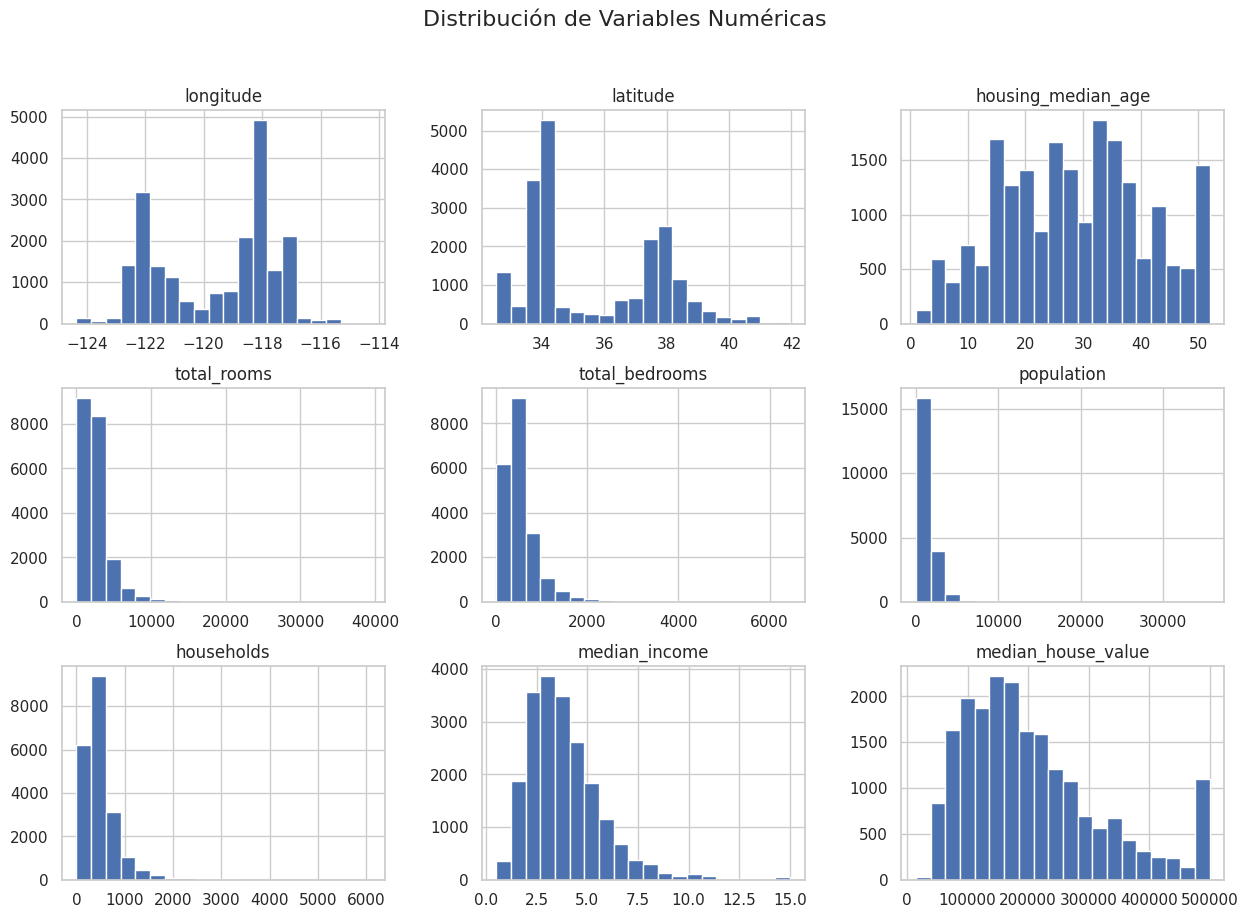

In [10]:
# Histogramas de variables numéricas
# Permiten observar la distribución y dispersión de los datos

df.hist(bins=20, figsize=(15,10))
plt.suptitle("Distribución de Variables Numéricas", fontsize=16)
plt.show()

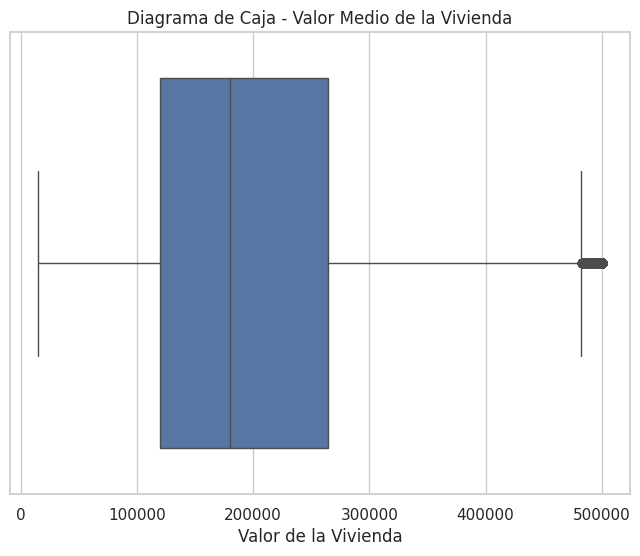

In [11]:
# Boxplot del valor medio de vivienda
# Permite identificar valores atípicos

plt.figure(figsize=(8,6))
sns.boxplot(x=df["median_house_value"])

plt.title("Diagrama de Caja - Valor Medio de la Vivienda")
plt.xlabel("Valor de la Vivienda")
plt.show()

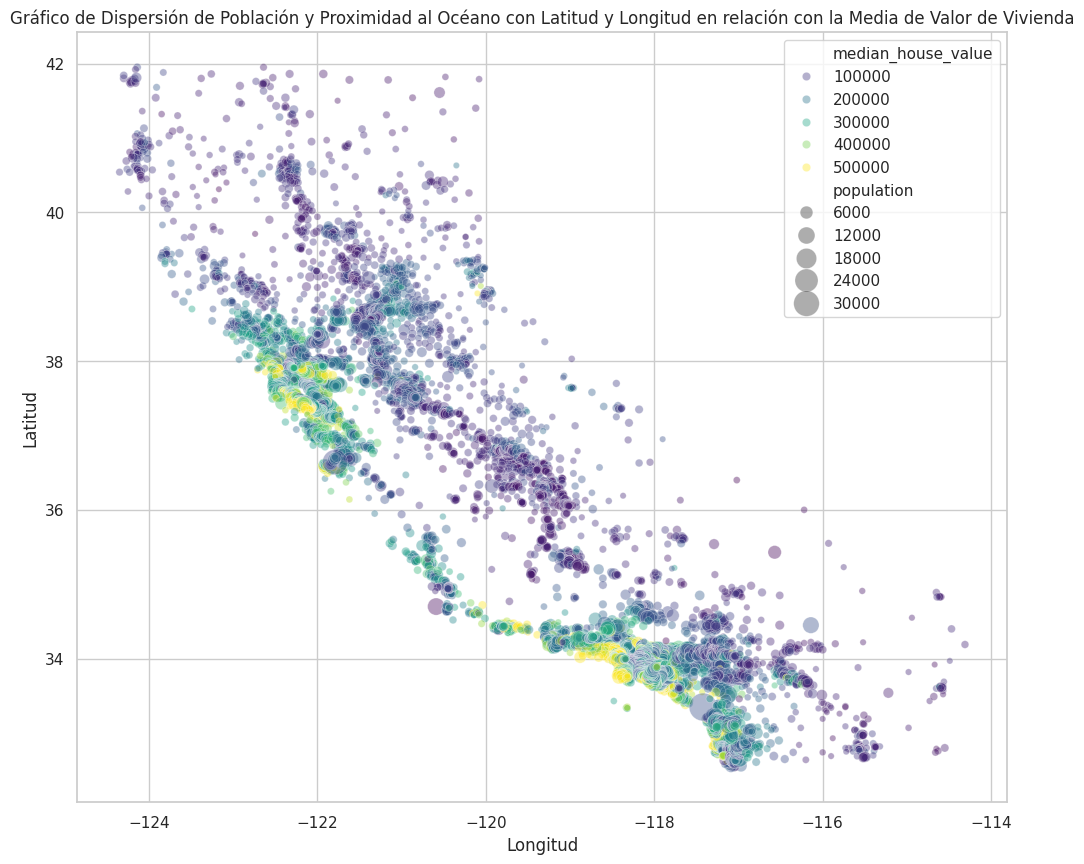

In [12]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='median_house_value', # Color by median house value
    size='population',        # Size by population
    sizes=(20, 400),          # Range of sizes for points
    alpha=0.4,                # Transparency
    palette='viridis'         # Colormap
)
plt.title('Gráfico de Dispersión de Población y Proximidad al Océano con Latitud y Longitud en relación con la Media de Valor de Vivienda')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True)
plt.show()

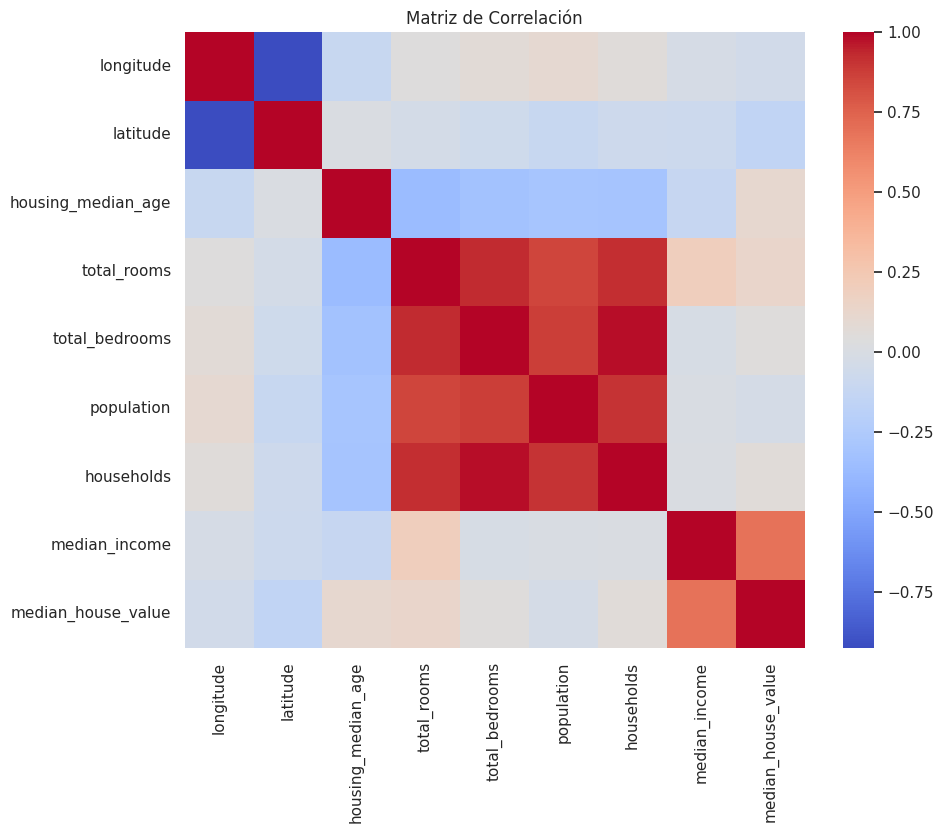

In [13]:
# Matriz de correlación entre variables numéricas

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)

plt.title("Matriz de Correlación")
plt.show()


# Proceso ETL (Extracción, Transformación y Carga)

En esta sección se implementa el proceso ETL aplicado al dataset de vivienda obtenido desde Kaggle.

El proceso incluye:

Extracción: Carga correcta del dataset.

Transformación: Limpieza de datos, tratamiento de valores faltantes, verificación de tipos de datos e ingeniería de características.

Carga: Exportación del dataset limpio para su uso posterior.


In [14]:
# Columnas con valores faltantes y cúantos
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [15]:
# Devuelve un DataFrame del mismo tamaño que df, pero en lugar de los valores originales, contiene True en cada posición donde el valor es nulo (NaN) y False donde el valor está presente.
df.isnull()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
20635,False,False,False,False,False,False,False,False,False,False
20636,False,False,False,False,False,False,False,False,False,False
20637,False,False,False,False,False,False,False,False,False,False
20638,False,False,False,False,False,False,False,False,False,False


In [16]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [17]:
df.dtypes

,0
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity,object


In [18]:
# Crear nueva variable categórica según rangos de precio

df["price_category"] = pd.cut(
    df["median_house_value"],
    bins=[0,150000,300000,500000,1000000],
    labels=["Bajo","Medio","Alto","Muy Alto"]
)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,price_category
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,Alto
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,Alto
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,Alto
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,Alto
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,Alto


Se creó una nueva variable denominada price_category que clasifica las viviendas en rangos de precio, facilitando análisis categóricos posteriores.

In [19]:
# Guardar dataset limpio
df.to_csv("cleaned_housing.csv", index=False)

El dataset fue transformado y almacenado en un nuevo archivo denominado cleaned_housing.csv, listo para análisis avanzado o modelado predictivo.